In [1]:
# 1. IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
# 2. LOAD SALES DATA
# Set USE_UPLOAD = True to upload your own sales CSV file.
# Required columns: CustomerID, ProductID, Quantity
# If USE_UPLOAD = False, a sample sales dataset is generated.

USE_UPLOAD = False

if USE_UPLOAD:
    from google.colab import files
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    df = pd.read_csv(file_name)
else:
    np.random.seed(42)

    n_customers, n_products, n_records = 500, 100, 20000

    # Customers and products belong to 5 hidden groups.
    # Customers buy more of the products from their own group.
    customer_group = np.random.randint(0, 5, n_customers)
    product_group = np.random.randint(0, 5, n_products)

    customers = np.random.randint(0, n_customers, n_records)
    products = np.random.randint(0, n_products, n_records)

    same_group = customer_group[customers] == product_group[products]

    quantity = np.where(
        same_group,
        np.random.randint(3, 6, n_records),
        np.random.randint(1, 3, n_records)
    )

    df = pd.DataFrame({
        "CustomerID": ["C" + str(i) for i in customers],
        "ProductID": ["P" + str(i) for i in products],
        "Quantity": quantity
    })

    df = df.drop_duplicates(subset=["CustomerID", "ProductID"])

print("\nDataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())



Dataset Shape: (16443, 3)

First 5 Rows:
  CustomerID ProductID  Quantity
0       C202       P46         1
1       C251       P90         2
2       C228       P49         2
3       C163       P88         1
4       C226       P25         2


In [3]:
# 3. PREPROCESS DATA

df = df.dropna(subset=["CustomerID", "ProductID", "Quantity"])

# Encode customer and product IDs as numbers
customer_encoder = LabelEncoder()
product_encoder = LabelEncoder()

df["customer"] = customer_encoder.fit_transform(df["CustomerID"])
df["product"] = product_encoder.fit_transform(df["ProductID"])

n_customers = df["customer"].nunique()
n_products = df["product"].nunique()

# Normalize quantity (purchase strength) to range 0-1
min_q, max_q = df["Quantity"].min(), df["Quantity"].max()
df["rating"] = (df["Quantity"] - min_q) / (max_q - min_q)

print("\nUnique Customers:", n_customers)
print("Unique Products:", n_products)
print("Total Transactions:", len(df))


Unique Customers: 500
Unique Products: 100
Total Transactions: 16443


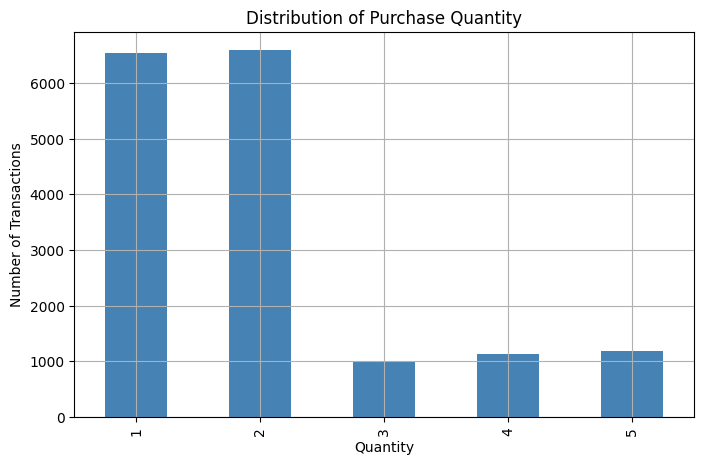

In [4]:
# 4. VISUALIZE SALES DATA

plt.figure(figsize=(8, 5))

df["Quantity"].value_counts().sort_index().plot(kind="bar", color="steelblue")

plt.title("Distribution of Purchase Quantity")
plt.xlabel("Quantity")
plt.ylabel("Number of Transactions")
plt.grid(True)
plt.show()

In [5]:
# 5. TRAIN-TEST SPLIT

train_df, test_df = train_test_split(df, test_size=0.20, random_state=42)

print("\nTraining Records:", len(train_df))
print("Testing Records:", len(test_df))


Training Records: 13154
Testing Records: 3289


In [6]:
# 6. BUILD DEEP LEARNING RECOMMENDATION MODEL

EMBEDDING_DIM = 32

# Inputs
customer_input = Input(shape=(1,), name="customer_input")
product_input = Input(shape=(1,), name="product_input")

# Embedding layers
customer_embedding = Embedding(n_customers, EMBEDDING_DIM)(customer_input)
product_embedding = Embedding(n_products, EMBEDDING_DIM)(product_input)

customer_vector = Flatten()(customer_embedding)
product_vector = Flatten()(product_embedding)

# Combine customer and product vectors
x = Concatenate()([customer_vector, product_vector])

# Fully connected layers
x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)
x = Dense(32, activation="relu")(x)

# Output: predicted purchase score
output = Dense(1, activation="sigmoid")(x)

model = Model([customer_input, product_input], output)

print("\nRECOMMENDATION MODEL:")
model.summary()


RECOMMENDATION MODEL:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ customer_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 32)     │     16,000 │ customer_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 32)     │      3,200 │ product_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,473 (99.50 KB)

 Trainable params: 25,473 (99.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 7. COMPILE MODEL

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# 8. TRAIN MODEL

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    [train_df["customer"], train_df["product"]],
    train_df["rating"],
    epochs=30,
    batch_size=128,
    validation_split=0.10,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.1070 - mae: 0.2697 - val_loss: 0.0876 - val_mae: 0.2145
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0852 - mae: 0.2133 - val_loss: 0.0889 - val_mae: 0.2185
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0839 - mae: 0.2149 - val_loss: 0.0899 - val_mae: 0.2213
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0831 - mae: 0.2150 - val_loss: 0.0905 - val_mae: 0.2243


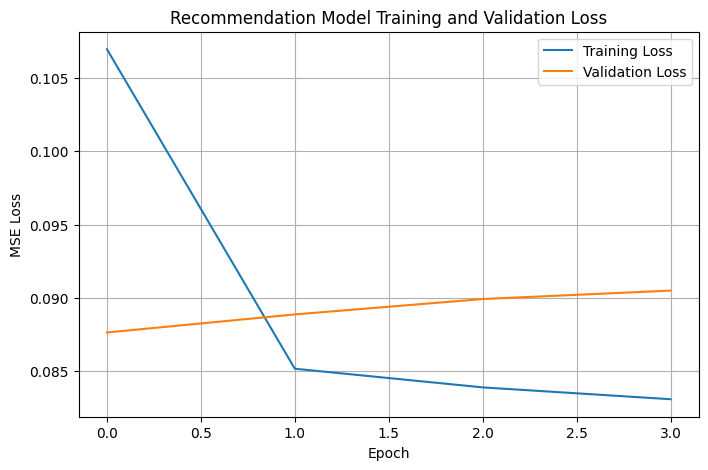

In [8]:
# 9. VISUALIZE TRAINING LOSS

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Recommendation Model Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(True)
plt.show()

In [9]:
# 10. EVALUATE MODEL

y_true = test_df["rating"].values
y_pred = model.predict(
    [test_df["customer"], test_df["product"]], verbose=0
).flatten()

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)

print("\nMean Squared Error (MSE):", round(mse, 4))
print("Mean Absolute Error (MAE):", round(mae, 4))
print("Root Mean Squared Error (RMSE):", round(rmse, 4))


Mean Squared Error (MSE): 0.0861
Mean Absolute Error (MAE): 0.2114
Root Mean Squared Error (RMSE): 0.2934


In [11]:
# 11. RECOMMEND PRODUCTS FOR A CUSTOMER

def recommend_products(customer_id, top_n=5):
    customer_code = customer_encoder.transform([customer_id])[0]

    # Products already purchased by the customer
    purchased = df[df["customer"] == customer_code]["product"].values

    # Products not yet purchased
    all_products = np.arange(n_products)
    new_products = np.setdiff1d(all_products, purchased)

    # Predict purchase score for each new product
    customer_array = np.full(len(new_products), customer_code)

    # Reshape inputs to (batch_size, 1) to match the model's Input shape
    scores = model.predict([customer_array.reshape(-1, 1), new_products.reshape(-1, 1)], verbose=0).flatten()

    # Select top N products
    top_index = np.argsort(scores)[::-1][:top_n]

    result = pd.DataFrame({
        "ProductID": product_encoder.inverse_transform(new_products[top_index]),
        "Predicted Score": np.round(scores[top_index], 4)
    })

    return result

sample_customer = df["CustomerID"].iloc[0]

print("\nTop 5 Recommended Products for Customer", sample_customer)
print(recommend_products(sample_customer, top_n=5).to_string(index=False))


Top 5 Recommended Products for Customer C202
ProductID  Predicted Score
      P59           0.3049
      P91           0.3039
      P82           0.3031
       P0           0.3013
      P49           0.2932


In [12]:
# 12. DISPLAY FINAL RESULTS

print("\n===================================")
print("          FINAL RESULT")
print("===================================")

print("Deep Learning Recommendation System trained successfully.")
print("Customers:", n_customers)
print("Products:", n_products)
print("Training Records:", len(train_df))
print("Testing Records:", len(test_df))
print("RMSE:", round(rmse, 4))
print("MAE:", round(mae, 4))


          FINAL RESULT
Deep Learning Recommendation System trained successfully.
Customers: 500
Products: 100
Training Records: 13154
Testing Records: 3289
RMSE: 0.2934
MAE: 0.2114
